In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("pszemraj/goodreads-bookgenres")

train_dataset = dataset['train']
validation_dataset = dataset['validation']
test_dataset = dataset['test']

print("Dataset Information:")
print(f"Training Set: {len(train_dataset)} entries")
print(f"Validation Set: {len(validation_dataset)} entries")
print(f"Test Set: {len(test_dataset)} entries")

# Display the features and data types
print("\nFeatures:")
for feature, feature_type in train_dataset.features.items():
    print(f"{feature}: {feature_type}")

# Show a sample from the training set
print("\nSample from Training Set:")
print(train_dataset[0])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/24.4k [00:00<?, ?B/s]

(…)-00000-of-00001-1ddc9bde2cb8caf1.parquet:   0%|          | 0.00/5.44M [00:00<?, ?B/s]

(…)-00000-of-00001-c69c3deb9f318ffd.parquet:   0%|          | 0.00/671k [00:00<?, ?B/s]

(…)-00000-of-00001-35cf4a77f73c1e63.parquet:   0%|          | 0.00/673k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7914 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/989 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/990 [00:00<?, ? examples/s]

Dataset Information:
Training Set: 7914 entries
Validation Set: 989 entries
Test Set: 990 entries

Features:
Book: Value(dtype='string', id=None)
Description: Value(dtype='string', id=None)
Genres: Sequence(feature=ClassLabel(names=['History & Politics', 'Health & Medicine', 'Mystery & Thriller', 'Arts & Design', 'Self-Help & Wellness', 'Sports & Recreation', 'Non-Fiction', 'Science Fiction & Fantasy', 'Countries & Geography', 'Other', 'Nature & Environment', 'Business & Finance', 'Romance', 'Philosophy & Religion', 'Literature & Fiction', 'Science & Technology', 'Children & Young Adult', 'Food & Cooking'], id=None), length=-1, id=None)

Sample from Training Set:
{'Book': 'The Last of the Mohicans (The Leatherstocking Tales, #2)', 'Description': "The wild rush of action in this classic frontier adventure story has made The Last of the Mohicans the most popular of James Fenimore Cooper's Leatherstocking Tales. Deep in the forests of upper New York State, the brave woodsman Hawkeye (Natt

In [ ]:
import numpy as np

genre_names = train_dataset.features["Genres"].feature.names

genre_counts = np.sum([np.array(row["Genres"]) for row in train_dataset], axis=0)
print("\nGenre Distribution in Training Set:")
for idx, count in enumerate(genre_counts):
    print(f"Genre {genre_names[idx]}: {count} occurrences")

genre_counts = np.sum([np.array(row["Genres"]) for row in validation_dataset], axis=0)
print("\nGenre Distribution in Validation Set:")
for idx, count in enumerate(genre_counts):
    print(f"Genre {genre_names[idx]}: {count} occurrences")

genre_counts = np.sum([np.array(row["Genres"]) for row in test_dataset], axis=0)
print("\nGenre Distribution in Test Set:")
for idx, count in enumerate(genre_counts):
    print(f"Genre {genre_names[idx]}: {count} occurrences")



Genre Distribution in Training Set:
Genre History & Politics: 1557 occurrences
Genre Health & Medicine: 163 occurrences
Genre Mystery & Thriller: 1348 occurrences
Genre Arts & Design: 92 occurrences
Genre Self-Help & Wellness: 876 occurrences
Genre Sports & Recreation: 110 occurrences
Genre Non-Fiction: 2642 occurrences
Genre Science Fiction & Fantasy: 1893 occurrences
Genre Countries & Geography: 1076 occurrences
Genre Other: 741 occurrences
Genre Nature & Environment: 283 occurrences
Genre Business & Finance: 380 occurrences
Genre Romance: 1349 occurrences
Genre Philosophy & Religion: 1246 occurrences
Genre Literature & Fiction: 4027 occurrences
Genre Science & Technology: 768 occurrences
Genre Children & Young Adult: 1526 occurrences
Genre Food & Cooking: 49 occurrences

Genre Distribution in Validation Set:
Genre History & Politics: 216 occurrences
Genre Health & Medicine: 16 occurrences
Genre Mystery & Thriller: 198 occurrences
Genre Arts & Design: 17 occurrences
Genre Self-Help 

In [ ]:
distinct_genres_indices = [0, 2, 6, 7, 12, 16]

# Filter the genre names to include only distinct genres
distinct_genres = [genre_names[idx] for idx in distinct_genres_indices]

def filter_distinct_genres(example):
    return any(example["Genres"][idx] == 1 for idx in distinct_genres_indices)

train_dataset_filtered = train_dataset.filter(filter_distinct_genres)
validation_dataset_filtered = validation_dataset.filter(filter_distinct_genres)
test_dataset_filtered = test_dataset.filter(filter_distinct_genres)

def update_genres(example):
    new_labels = [example["Genres"][idx] for idx in distinct_genres_indices]
    return {"Genres": new_labels}

train_dataset = train_dataset_filtered.map(update_genres)
validation_dataset = validation_dataset_filtered.map(update_genres)
test_dataset = test_dataset_filtered.map(update_genres)

# Verify the updated genre names and dataset
print("Distinct Genres:", distinct_genres)
print("Filtered Training Set Sample:", train_dataset_filtered[0])


Filter:   0%|          | 0/7914 [00:00<?, ? examples/s]

Filter:   0%|          | 0/989 [00:00<?, ? examples/s]

Filter:   0%|          | 0/990 [00:00<?, ? examples/s]

Map:   0%|          | 0/6472 [00:00<?, ? examples/s]

Map:   0%|          | 0/869 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Distinct Genres: ['History & Politics', 'Mystery & Thriller', 'Non-Fiction', 'Science Fiction & Fantasy', 'Romance', 'Children & Young Adult']
Filtered Training Set Sample: {'Book': 'The Last of the Mohicans (The Leatherstocking Tales, #2)', 'Description': "The wild rush of action in this classic frontier adventure story has made The Last of the Mohicans the most popular of James Fenimore Cooper's Leatherstocking Tales. Deep in the forests of upper New York State, the brave woodsman Hawkeye (Natty Bumppo) and his loyal Mohican friends Chingachgook and Uncas become embroiled in the bloody battles of the French and Indian War. The abduction of the beautiful Munro sisters by hostile savages, the treachery of the renegade brave Magua, the ambush of innocent settlers, and the thrilling events that lead to the final tragic confrontation between rival war parties create an unforgettable, spine-tingling picture of life on the frontier. And as the idyllic wilderness gives way to the forces of c

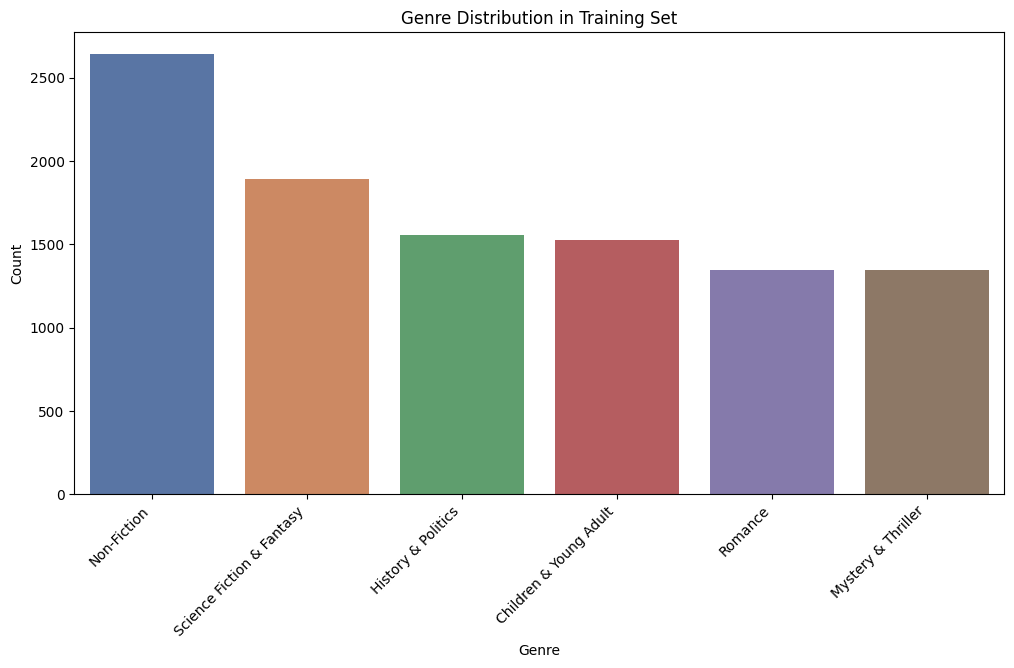

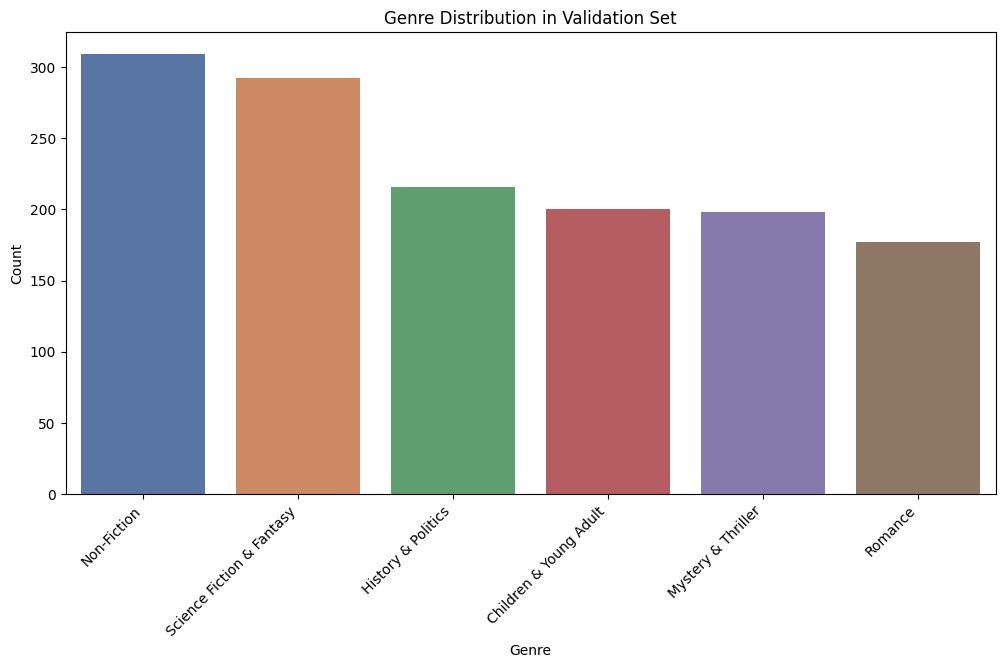

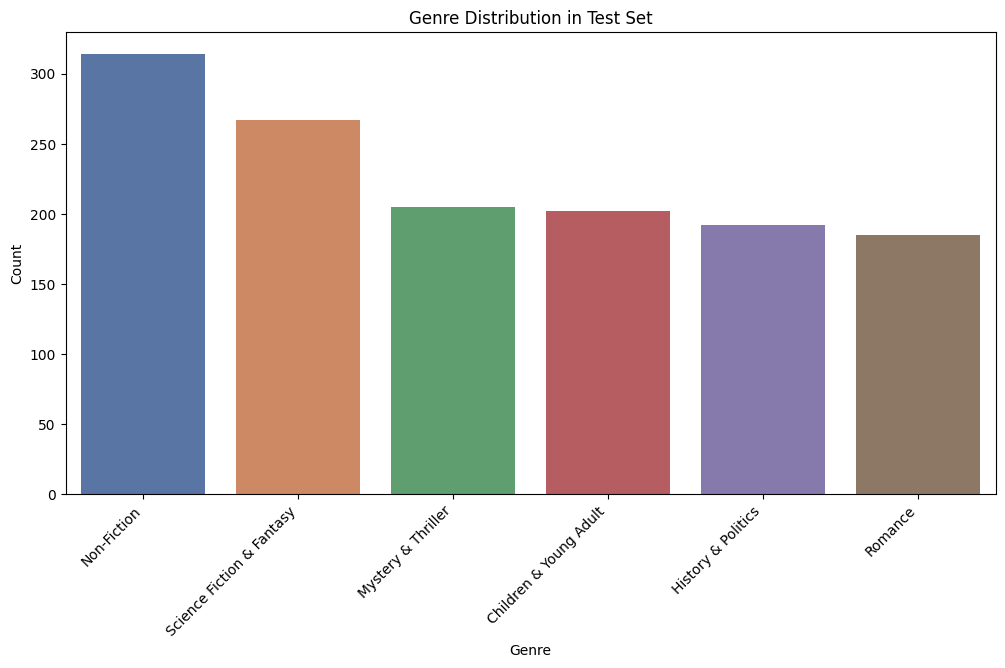

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def dataset_to_dataframe(dataset):
    data = {"Title": [], "Description": [], "Genres": []}
    for row in dataset:
        data["Title"].append(row["Book"])
        data["Description"].append(row["Description"])
        data["Genres"].append(row["Genres"])
    return pd.DataFrame(data)

train_df = dataset_to_dataframe(train_dataset)
validation_df = dataset_to_dataframe(validation_dataset)
test_df = dataset_to_dataframe(test_dataset)

def plot_genre_distribution(df, split_name):
    genre_sums = np.sum(df["Genres"].tolist(), axis=0)
    genre_distribution = pd.DataFrame({"Genre": distinct_genres, "Count": genre_sums}).sort_values(by="Count", ascending=False)

    # Create plot with colors based on the genre
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Genre", y="Count", data=genre_distribution, hue="Genre", dodge=False, palette="deep")
    plt.xticks(rotation=45, ha='right')
    plt.title(f"Genre Distribution in {split_name} Set")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.show()

# Wizualizacje rozkładu gatunków
plot_genre_distribution(train_df, "Training")
plot_genre_distribution(validation_df, "Validation")
plot_genre_distribution(test_df, "Test")


In [ ]:
# Check for missing values
print("Missing values in train dataset:")
print(train_df.isna().sum())

print("\nMissing values in validation dataset:")
print(validation_df.isna().sum())

print("\nMissing values in test dataset:")
print(test_df.isna().sum())

Missing values in train dataset:
Title          0
Description    0
Genres         0
dtype: int64

Missing values in validation dataset:
Title          0
Description    0
Genres         0
dtype: int64

Missing values in test dataset:
Title          0
Description    0
Genres         0
dtype: int64


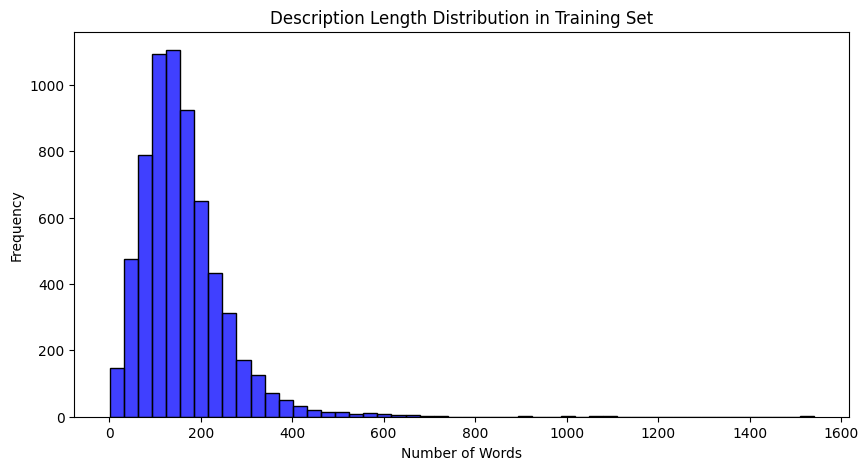

Training Set - Description Length Stats:
count    6472.000000
mean      159.586681
std        93.459632
min         1.000000
25%       100.750000
50%       144.000000
75%       199.000000
max      1541.000000
Name: Description, dtype: float64


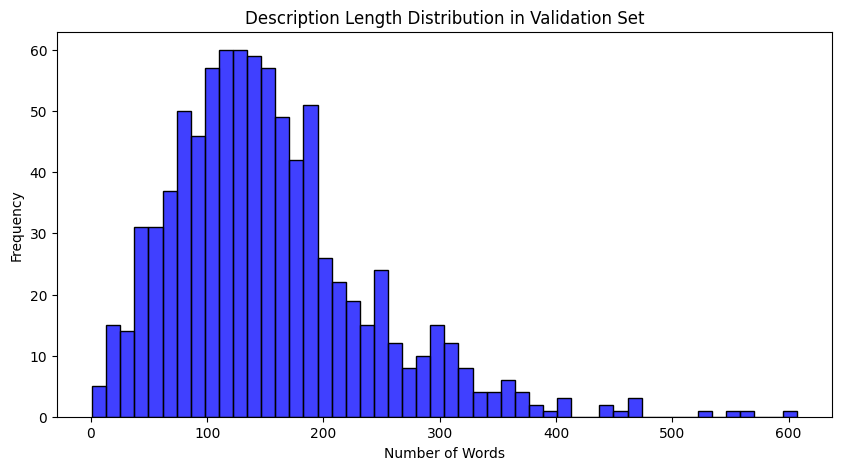

Validation Set - Description Length Stats:
count    869.000000
mean     153.850403
std       86.246983
min        1.000000
25%       95.000000
50%      140.000000
75%      191.000000
max      607.000000
Name: Description, dtype: float64


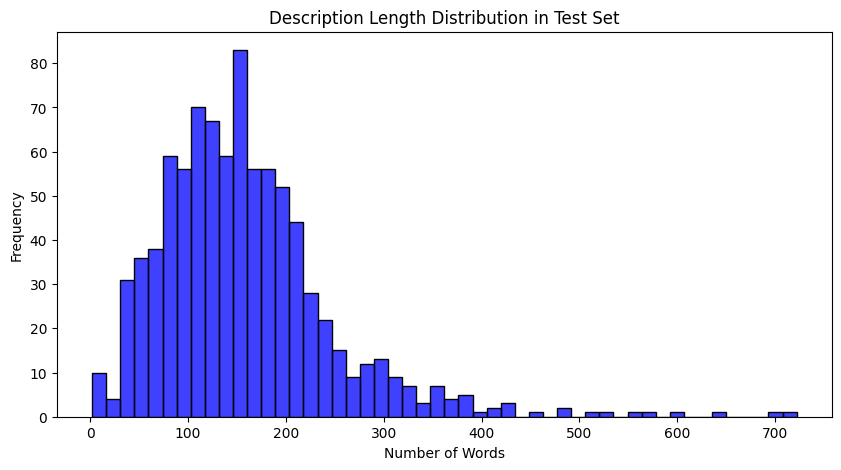

Test Set - Description Length Stats:
count    872.000000
mean     157.592890
std       89.791815
min        2.000000
25%       99.000000
50%      147.000000
75%      196.000000
max      722.000000
Name: Description, dtype: float64


In [ ]:
def analyze_description_length(df, split_name):
    description_lengths = df["Description"].apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(10, 5))
    sns.histplot(description_lengths, bins=50, color="blue")
    plt.title(f"Description Length Distribution in {split_name} Set")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()
    print(f"{split_name} Set - Description Length Stats:")
    print(description_lengths.describe())

analyze_description_length(train_df, "Training")
analyze_description_length(validation_df, "Validation")
analyze_description_length(test_df, "Test")

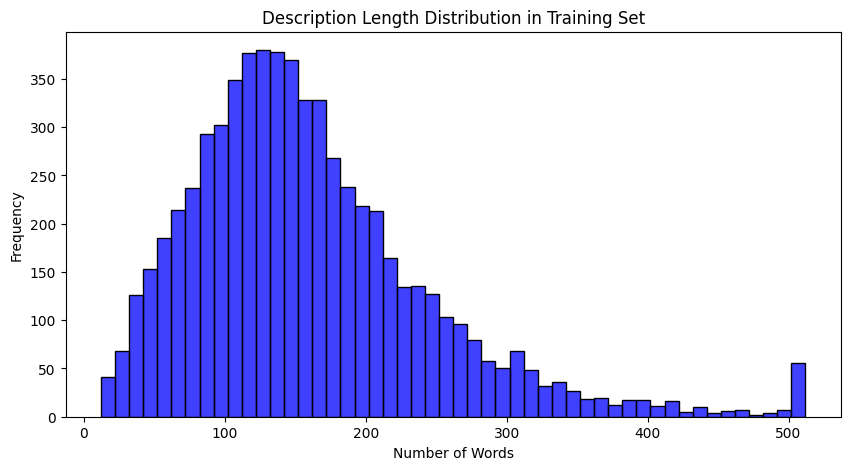

Training Set - Description Length Stats:
count    6435.000000
mean      159.334110
std        86.048673
min        12.000000
25%       101.000000
50%       145.000000
75%       200.000000
max       512.000000
Name: Description, dtype: float64


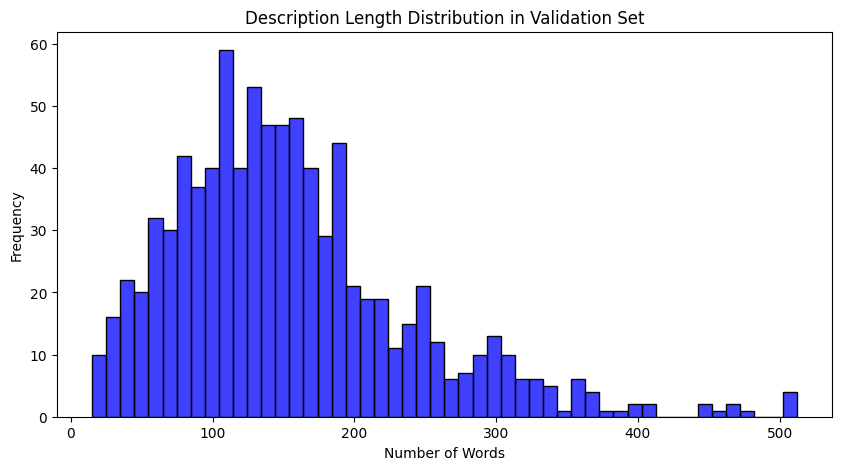

Validation Set - Description Length Stats:
count    864.000000
mean     154.489583
std       84.696144
min       15.000000
25%       96.000000
50%      141.000000
75%      191.250000
max      512.000000
Name: Description, dtype: float64


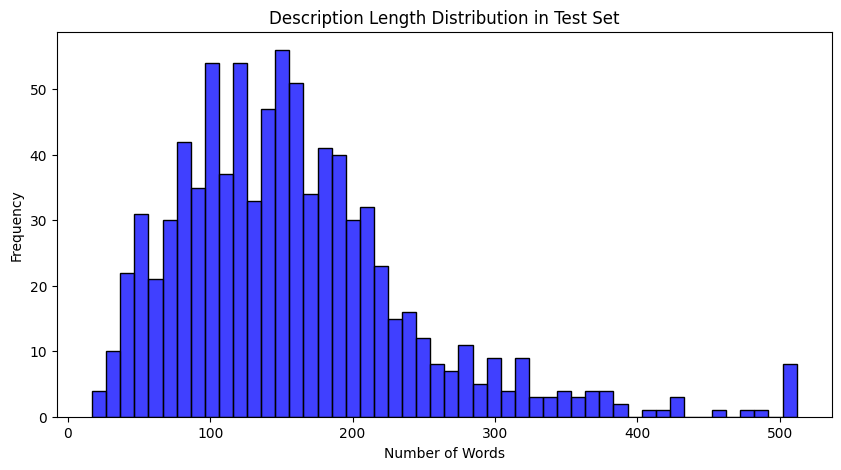

Test Set - Description Length Stats:
count    862.00000
mean     158.50000
std       84.51817
min       17.00000
25%      100.00000
50%      147.00000
75%      196.75000
max      512.00000
Name: Description, dtype: float64


In [ ]:
def filter_dataset(dataset, min_length=12, max_length=512):
    filtered_data = [
        row for row in dataset if len(str(row["Description"]).split()) >= min_length
    ]
    for row in filtered_data:
        description_words = str(row["Description"]).split()
        if len(description_words) > max_length:
            row["Description"] = " ".join(description_words[:max_length])
    return filtered_data

train_dataset = filter_dataset(train_dataset)
validation_dataset = filter_dataset(validation_dataset)
test_dataset = filter_dataset(test_dataset)

train_df = dataset_to_dataframe(train_dataset)
validation_df = dataset_to_dataframe(validation_dataset)
test_df = dataset_to_dataframe(test_dataset)

def analyze_description_length(df, split_name):
    description_lengths = df["Description"].apply(lambda x: len(str(x).split()))
    plt.figure(figsize=(10, 5))
    sns.histplot(description_lengths, bins=50, color="blue")
    plt.title(f"Description Length Distribution in {split_name} Set")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()
    print(f"{split_name} Set - Description Length Stats:")
    print(description_lengths.describe())

analyze_description_length(train_df, "Training")
analyze_description_length(validation_df, "Validation")
analyze_description_length(test_df, "Test")

In [ ]:
! pip install scikit-learn scikit-multilearn datasets nltk

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('wordnet')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 9.2 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Initialize stopwords, stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return ' '.join(tokens)

def add_title(example):
   text = f"{example['Book']}.\n{example['Description']}"
   return text

texts_train = [add_title(ex) for ex in train_dataset]
texts_validation = [add_title(ex) for ex in validation_dataset]
texts_test = [add_title(ex) for ex in test_dataset]

preprocessed_train = [preprocess_text(ex) for ex in texts_train]
preprocessed_validation = [preprocess_text(ex) for ex in texts_validation]
preprocessed_test = [preprocess_text(ex) for ex in texts_test]

print(preprocessed_train[0])

last mohican leatherstock tale 2 wild rush action classic frontier adventur stori made last mohican popular jame fenimor cooper leatherstock tale deep forest upper new york state brave woodsman hawkey natti bumppo loyal mohican friend chingachgook unca becom embroil bloodi battl french indian war abduct beauti munro sister hostil savag treacheri renegad brave magua ambush innoc settler thrill event lead final tragic confront rival war parti creat unforgett spinetingl pictur life frontier idyl wilder give way forc civil novel present move portray vanish race end way life great american forest


In [ ]:
# Convert the 'Genres' column to lists of labels
train_labels = [row['Genres'] for row in train_dataset]
validation_labels = [row['Genres'] for row in validation_dataset]
test_labels = [row['Genres'] for row in test_dataset]

vectorizer = TfidfVectorizer(max_features=10000)

X_train = vectorizer.fit_transform(preprocessed_train)
X_validation = vectorizer.transform(preprocessed_validation)
X_test = vectorizer.transform(preprocessed_test)

In [ ]:
# Convert labels to binary format for compatibility with scikit-multilearn
y_train = np.array(train_labels)
y_validation = np.array(validation_labels)
y_test = np.array(test_labels)

In [ ]:
from sklearn.svm import SVC
from skmultilearn.problem_transform import BinaryRelevance

classifier2 = BinaryRelevance(classifier=SVC(class_weight='balanced', kernel="rbf"), require_dense=[False, True])
classifier2.fit(X_train, y_train)


BinaryRelevance(classifier=SVC(class_weight='balanced'),
                require_dense=[False, True])

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
)
import numpy as np

def evaluate_model(y_test, y_pred):
    # Convert sparse matrix to dense array if needed
    if not isinstance(y_pred, np.ndarray):
        y_pred = y_pred.toarray()

    metrics = {
        "Hamming Accuracy": 1 - hamming_loss(y_test, y_pred),
        "Zero-shot Accuracy": accuracy_score(y_test, y_pred),
        "Micro Precision": precision_score(y_test, y_pred, average='micro', zero_division=1),
        "Micro Recall": recall_score(y_test, y_pred, average='micro', zero_division=1),
        "Micro F1-Score": f1_score(y_test, y_pred, average='micro'),
        "Macro Precision": precision_score(y_test, y_pred, average='macro', zero_division=1),
        "Macro Recall": recall_score(y_test, y_pred, average='macro', zero_division=1),
        "Macro F1-Score": f1_score(y_test, y_pred, average='macro'),
    }

    print("Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")

    return metrics


In [ ]:
y_pred2 = classifier2.predict(X_test)

y_pred_dense2 = y_pred2.toarray()
metrics = evaluate_model(y_test, y_pred_dense2)

Evaluation Metrics:
Hamming Accuracy: 0.8633
Zero-shot Accuracy: 0.4664
Micro Precision: 0.7756
Micro Recall: 0.6718
Micro F1-Score: 0.7200
Macro Precision: 0.7652
Macro Recall: 0.6517
Macro F1-Score: 0.7006



Error Analysis:
Label 0:
True Positives: 120, False Positives: 48
False Negatives: 70, True Negatives: 624
Label 1:
True Positives: 115, False Positives: 29
False Negatives: 90, True Negatives: 628
Label 2:
True Positives: 271, False Positives: 55
False Negatives: 38, True Negatives: 498
Label 3:
True Positives: 177, False Positives: 40
False Negatives: 88, True Negatives: 557
Label 4:
True Positives: 99, False Positives: 36
False Negatives: 83, True Negatives: 644
Label 5:
True Positives: 127, False Positives: 55
False Negatives: 75, True Negatives: 605


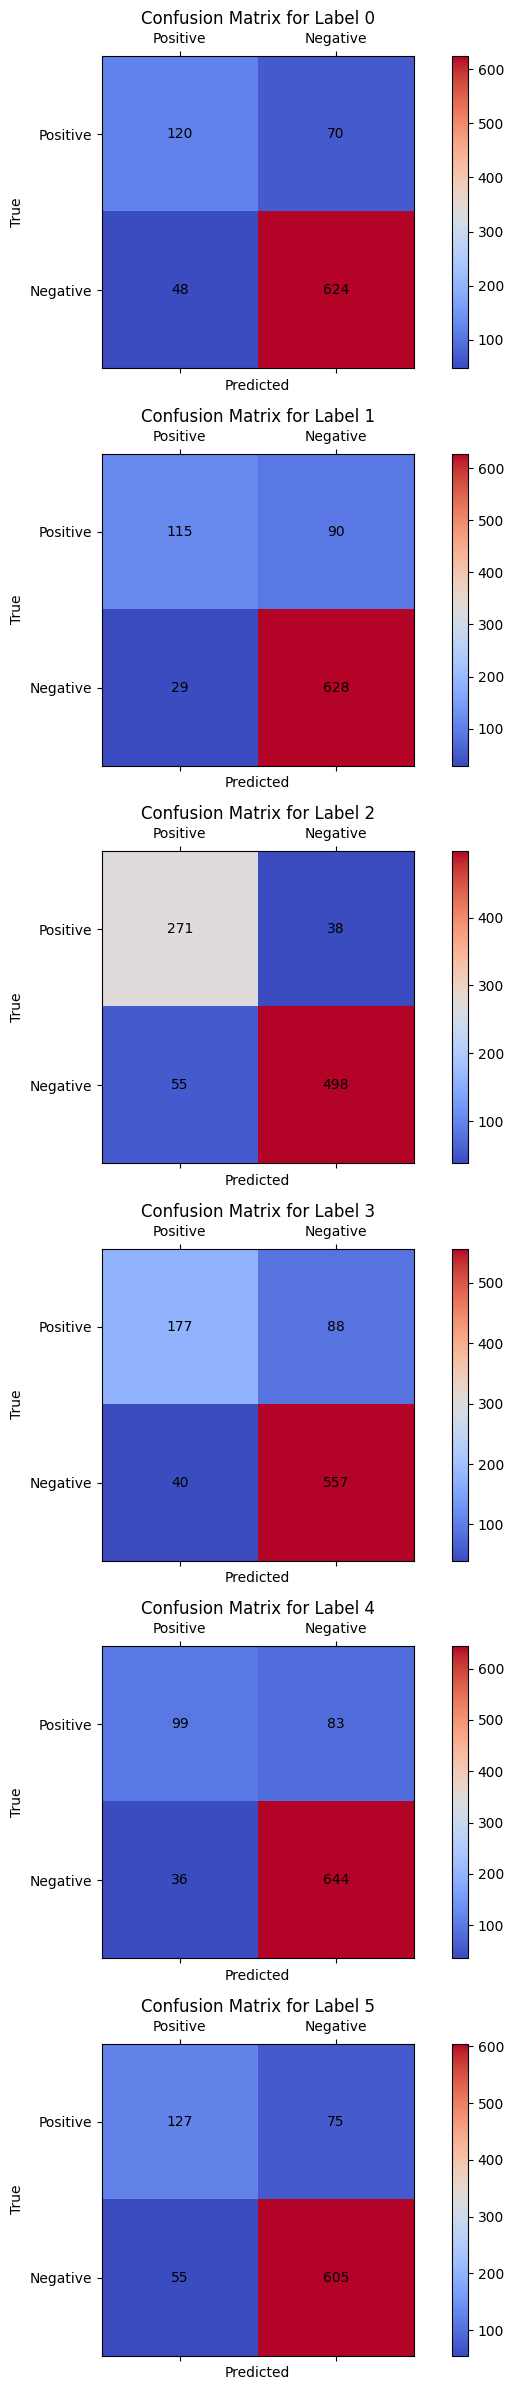

In [ ]:
from matplotlib import pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix

def error_analysis(y_test, y_pred):
    confusion_matrices = multilabel_confusion_matrix(y_test, y_pred)
    print("\nError Analysis:")
    for i, cm in enumerate(confusion_matrices):
        tn, fp, fn, tp = cm.ravel()
        print(f"Label {i}:")
        print(f"True Positives: {tp}, False Positives: {fp}")
        print(f"False Negatives: {fn}, True Negatives: {tn}")

error_analysis(y_test, y_pred_dense2)

def plot_confusion_matrices(y_test, y_pred, class_names=None):
    confusion_matrices = multilabel_confusion_matrix(y_test, y_pred)
    num_labels = confusion_matrices.shape[0]

    fig, axes = plt.subplots(nrows=num_labels, ncols=1, figsize=(8, 4 * num_labels))
    if num_labels == 1:
        axes = [axes]

    for i, cm in enumerate(confusion_matrices):
        tn, fp, fn, tp = cm.ravel()
        matrix = np.array([[tp, fn], [fp, tn]])

        ax = axes[i]
        cax = ax.matshow(matrix, cmap="coolwarm")
        plt.colorbar(cax, ax=ax)
        ax.set_title(f"Confusion Matrix for Label {i}" + (f": {class_names[i]}" if class_names else ""))
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks([0, 1], labels=["Positive", "Negative"])
        ax.set_yticks([0, 1], labels=["Positive", "Negative"])
        for (x, y), value in np.ndenumerate(matrix):
            ax.text(y, x, f"{value}", va="center", ha="center")

    plt.tight_layout()
    plt.show()

# Example use case: Replace `y_test_dense` and `y_pred_dense2` with your actual arrays.
plot_confusion_matrices(y_test, y_pred_dense2)


In [ ]:
!pip install transformers datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 16.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("pszemraj/goodreads-bookgenres")

classes = dataset["train"].features["Genres"].feature.names

id2class = {str(i): class_name for i, class_name in enumerate(classes)}
class2id = {class_name: str(i) for i, class_name in enumerate(classes)}

print("id2class:", id2class)
print("class2id:", class2id)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/24.4k [00:00<?, ?B/s]

(…)-00000-of-00001-1ddc9bde2cb8caf1.parquet:   0%|          | 0.00/5.44M [00:00<?, ?B/s]

(…)-00000-of-00001-c69c3deb9f318ffd.parquet:   0%|          | 0.00/671k [00:00<?, ?B/s]

(…)-00000-of-00001-35cf4a77f73c1e63.parquet:   0%|          | 0.00/673k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7914 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/989 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/990 [00:00<?, ? examples/s]

id2class: {'0': 'History & Politics', '1': 'Health & Medicine', '2': 'Mystery & Thriller', '3': 'Arts & Design', '4': 'Self-Help & Wellness', '5': 'Sports & Recreation', '6': 'Non-Fiction', '7': 'Science Fiction & Fantasy', '8': 'Countries & Geography', '9': 'Other', '10': 'Nature & Environment', '11': 'Business & Finance', '12': 'Romance', '13': 'Philosophy & Religion', '14': 'Literature & Fiction', '15': 'Science & Technology', '16': 'Children & Young Adult', '17': 'Food & Cooking'}
class2id: {'History & Politics': '0', 'Health & Medicine': '1', 'Mystery & Thriller': '2', 'Arts & Design': '3', 'Self-Help & Wellness': '4', 'Sports & Recreation': '5', 'Non-Fiction': '6', 'Science Fiction & Fantasy': '7', 'Countries & Geography': '8', 'Other': '9', 'Nature & Environment': '10', 'Business & Finance': '11', 'Romance': '12', 'Philosophy & Religion': '13', 'Literature & Fiction': '14', 'Science & Technology': '15', 'Children & Young Adult': '16', 'Food & Cooking': '17'}


In [ ]:
from transformers import AutoTokenizer

model_path = 'microsoft/deberta-v3-small'

tokenizer = AutoTokenizer.from_pretrained(model_path)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [ ]:
def filter_dataset(example, min_length=10, max_length=512):
    # Check if description meets minimum length
    if len(str(example["Description"]).split()) < min_length:
        return False
    # Truncate descriptions longer than max_length
    description_words = str(example["Description"]).split()
    if len(description_words) > max_length:
        example["Description"] = " ".join(description_words[:max_length])
    return True

dataset = dataset.filter(filter_dataset)

def preprocess_function(example):
   text = f"{example['Book']}.\n{example['Description']}"
   labels = [1. if label == 1 else 0. for label in example['Genres']]

   example = tokenizer(text, truncation=True, max_length=512)
   example['labels'] = labels
   return example

tokenized_dataset = dataset.map(preprocess_function)

Filter:   0%|          | 0/7914 [00:00<?, ? examples/s]

Filter:   0%|          | 0/989 [00:00<?, ? examples/s]

Filter:   0%|          | 0/990 [00:00<?, ? examples/s]

Map:   0%|          | 0/7865 [00:00<?, ? examples/s]

Map:   0%|          | 0/984 [00:00<?, ? examples/s]

Map:   0%|          | 0/978 [00:00<?, ? examples/s]

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score, hamming_loss
import numpy as np
import torch
from transformers import EvalPrediction

def multi_label_metrics(predictions, labels, threshold=0.4):
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(predictions))
    probs_np = probs.numpy()  # Convert to numpy for sklearn metrics

    # Threshold probabilities to get binary predictions
    y_pred = (probs_np >= threshold).astype(int)
    y_true = labels

    metrics = {
        'Hamming Accuracy': 1 - hamming_loss(y_true, y_pred),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Micro F1-Score': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'Micro Precision': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'Micro Recall': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'Macro F1-Score': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    }

    return metrics

def compute_metrics(p: EvalPrediction):
    """
    Wrapper function for HuggingFace's Trainer
    """
    preds = p.predictions[0] if isinstance(p.predictions, tuple) else p.predictions
    return multi_label_metrics(predictions=preds, labels=p.label_ids)



In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding


model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=len(classes),
    id2label=id2class,
    label2id=class2id,
    problem_type="multi_label_classification",
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="multilab-model",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to=["none"],
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/24.4k [00:00<?, ?B/s]

(…)-00000-of-00001-1ddc9bde2cb8caf1.parquet:   0%|          | 0.00/5.44M [00:00<?, ?B/s]

(…)-00000-of-00001-c69c3deb9f318ffd.parquet:   0%|          | 0.00/671k [00:00<?, ?B/s]

(…)-00000-of-00001-35cf4a77f73c1e63.parquet:   0%|          | 0.00/673k [00:00<?, ?B/s]

...

Map:   0%|          | 0/863 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-2-342e85583d6d>:115: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Hamming accuracy,Accuracy,Micro f1-score,Micro precision,Micro recall,Macro f1-score,Macro precision,Macro recall
1,0.428400,0.318509,0.874807,0.512731,0.752950,0.796296,0.714079,0.730797,0.795652,0.692753
2,0.257100,0.286298,0.886574,0.554398,0.788337,0.786073,0.790614,0.775131,0.777139,0.775857
3,0.213700,0.294005,0.891590,0.568287,0.798711,0.792466,0.805054,0.787112,0.785052,0.790460
4,0.162900,0.304595,0.894097,0.575231,0.801015,0.804221,0.797834,0.789387,0.794908,0.784953


TrainOutput(global_step=3224, training_loss=0.25335132513685205, metrics={'train_runtime': 2952.3183, 'train_samples_per_second': 8.727, 'train_steps_per_second': 1.092, 'total_flos': 5038431756243480.0, 'train_loss': 0.25335132513685205, 'epoch': 4.0})

In [ ]:
eval_results = trainer.predict(tokenized_dataset["test"])
predictions = eval_results.predictions  
true_labels = np.array(tokenized_dataset["test"]["labels"])

metrics = multi_label_metrics(predictions, true_labels)
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")


Hamming Accuracy: 0.8857
Accuracy: 0.5365
Micro F1-Score: 0.7839
Micro Precision: 0.7749
Micro Recall: 0.7932
Macro F1-Score: 0.7761
Macro Precision: 0.7710
Macro Recall: 0.7857



Error Analysis:
Label 0:
True Positives: 146, False Positives: 45
False Negatives: 44, True Negatives: 628
Label 1:
True Positives: 134, False Positives: 24
False Negatives: 71, True Negatives: 634
Label 2:
True Positives: 252, False Positives: 40
False Negatives: 58, True Negatives: 513
Label 3:
True Positives: 192, False Positives: 29
False Negatives: 73, True Negatives: 569
Label 4:
True Positives: 110, False Positives: 28
False Negatives: 72, True Negatives: 653
Label 5:
True Positives: 135, False Positives: 30
False Negatives: 67, True Negatives: 631


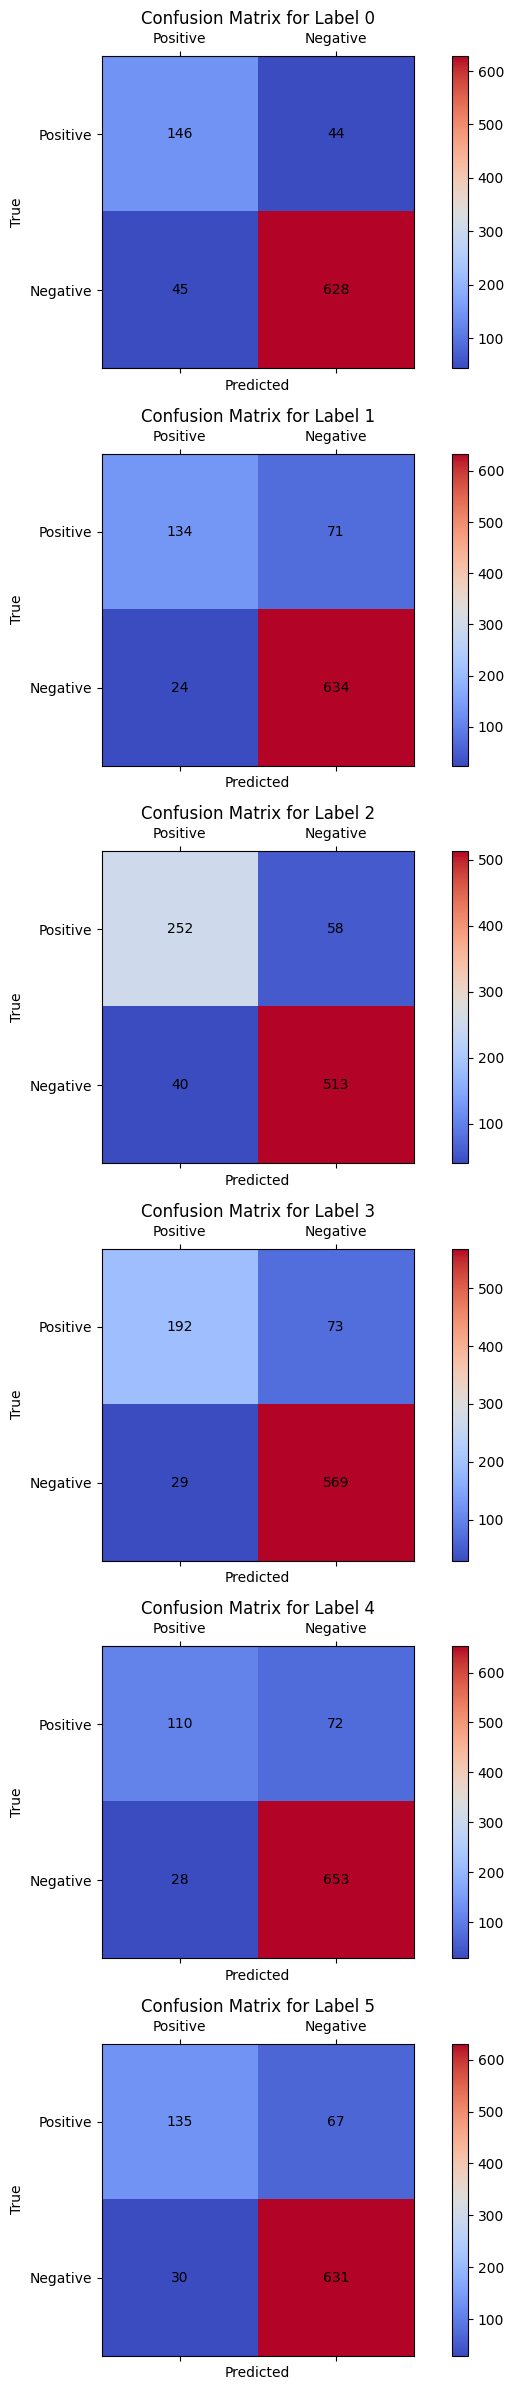

In [ ]:
from matplotlib import pyplot as plt
from sklearn.metrics import multilabel_confusion_matrix

threshold = 0.4
binary_predictions = (predictions > threshold).astype(int)

def error_analysis(y_test, y_pred):
    confusion_matrices = multilabel_confusion_matrix(y_test, y_pred)
    print("\nError Analysis:")
    for i, cm in enumerate(confusion_matrices):
        tn, fp, fn, tp = cm.ravel()
        print(f"Label {i}:")
        print(f"True Positives: {tp}, False Positives: {fp}")
        print(f"False Negatives: {fn}, True Negatives: {tn}")

error_analysis(true_labels, binary_predictions)

def plot_confusion_matrices(y_test, y_pred, class_names=None):
    confusion_matrices = multilabel_confusion_matrix(y_test, y_pred)
    num_labels = confusion_matrices.shape[0]

    fig, axes = plt.subplots(nrows=num_labels, ncols=1, figsize=(8, 4 * num_labels))
    if num_labels == 1:
        axes = [axes]

    for i, cm in enumerate(confusion_matrices):
        tn, fp, fn, tp = cm.ravel()
        matrix = np.array([[tp, fn], [fp, tn]])

        ax = axes[i]
        cax = ax.matshow(matrix, cmap="coolwarm")
        plt.colorbar(cax, ax=ax)
        ax.set_title(f"Confusion Matrix for Label {i}" + (f": {class_names[i]}" if class_names else ""))
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks([0, 1], labels=["Positive", "Negative"])
        ax.set_yticks([0, 1], labels=["Positive", "Negative"])
        for (x, y), value in np.ndenumerate(matrix):
            ax.text(y, x, f"{value}", va="center", ha="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(true_labels, binary_predictions)
